# Accessible Scatterplots

This notebook is a standalone teaching resource for creating accessible scatterplots with Matplotlib and describing it with MatplotAlt.

## What this graph is used for

Scatterplots are used to represent relationships between two variables and to reveal correlation or clustering patterns.

## How to make it more accessible

For accessibility, clearly identify what each axis represents, use meaningful contextual labels, increase marker size, provide a descriptive title, and use grid lines where they support reading values. Use high-contrast markers and do not depend on color alone to convey meaning.

## Setup

This notebook requires `matplotlib` and `matplotalt`; the heatmap notebook also uses `numpy`. If MatplotAlt is not installed, install it in your Python environment with `pip install matplotalt`.


### MatplotAlt description levels used in this notebook

The notebook generates descriptions at all four description levels using MatplotAlt:

- **Level 1:** axes and visual encodings such as color.
- **Level 2:** Level 1 plus statistics about the data.
- **Level 3:** Level 2 plus trends and relationships/correlation where supported.
- **Level 4:** broader contextual description. MatplotAlt's documentation indicates that Level 4 is available through its API/VLM functions, so this notebook uses `show_with_api_alt` for Level 4 and reads the API key from the `OPENAI_API_KEY` environment variable.

For Levels 1–3, the notebook uses the rule-based `show_with_alt` function. For Level 4, set an `OPENAI_API_KEY` in the environment before running the description cell.


In [ ]:
import os
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from matplotalt import show_with_alt, show_with_api_alt

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")


def show_all_description_levels(build_plot, 
                                chart_type=None,
                                max_rule_based_level=3,
):
    """Plot the figure and display MatplotAlt descriptions at Levels 1–4."""

    # MatplotAlt's rule-based descriptions support Levels 1–3.
    for level in range(1, max_rule_based_level + 1):
        plt.close("all")
        build_plot()
        display(Markdown(f"#### Level {level} description"))
        kwargs = {
            "desc_level": level, 
            "methods": ["markdown"],
        }
        if chart_type is not None:
            kwargs["chart_type"] = chart_type
        show_with_alt(**kwargs)

    # Level 4 uses MatplotAlt's API/VLM description function.
    plt.close("all")
    display(Markdown("#### Level 4 description"))
    if OPENAI_API_KEY:
        build_plot()
        kwargs = {
            "methods": ["markdown"],
            "use_starter_alt_in_prompt": True,
        }
        if chart_type is not None:
            kwargs["chart_type"] = chart_type
        show_with_api_alt(OPENAI_API_KEY, **kwargs)
    else:
        display(Markdown(
            "**Level 4 was not generated because `OPENAI_API_KEY` is not set.** "
            "Set that environment variable and rerun this cell to generate the broader-context "
            "Level 4 description with MatplotAlt."
        ))


## Accessible example

The code below showcases an accessibility-aware example of a scatterplot also presented in the Guidelines document.

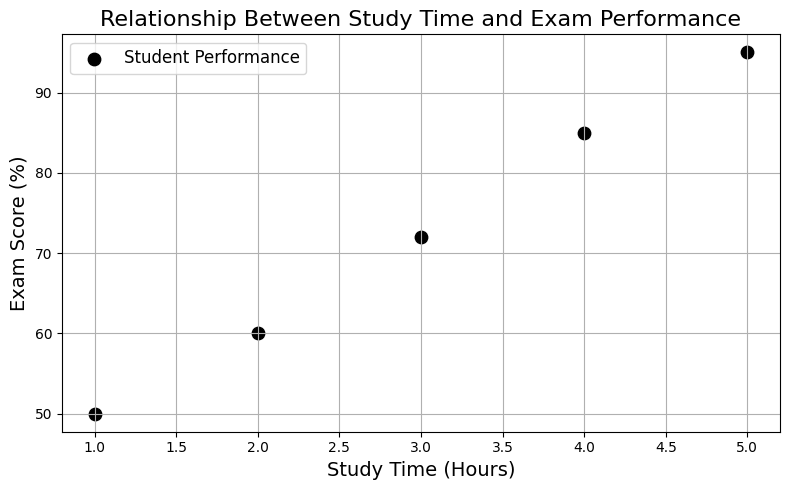

In [4]:
import matplotlib.pyplot as plt

study_hours = [1, 2, 3, 4, 5]
exam_scores = [50, 60, 72, 85, 95]

plt.figure(figsize=(8, 5))

plt.scatter(
    study_hours,
    exam_scores,
    color="black",
    marker="o",
    s=80,
    label="Student Performance"
)

plt.xlabel("Study Time (Hours)", fontsize=14)
plt.ylabel("Exam Score (%)", fontsize=14)
plt.title("Relationship Between Study Time and Exam Performance", fontsize=16)

plt.grid(True)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


### MatplotAlt descriptions for the graph example

The next cell recreates the same graph and generates Levels 1–3 with `show_with_alt`. It generates Level 4 with `show_with_api_alt` when `OPENAI_API_KEY` is available.

#### Level 1 description

A scatter plot titled 'relationship between study time and exam performance'. Study time (hours) is plotted on the x-axis from 0.5 to 5.5 and exam score (%) is plotted on the y-axis from 40 to 100, both using linear scales. Student performance is plotted in black.
data table:

| study time (hours) | exam score (%) |
| ------------------ | -------------- |
| 1                  | 50             |
| 2                  | 60             |
| 3                  | 72             |
| 4                  | 85             |
| 5                  | 95             |


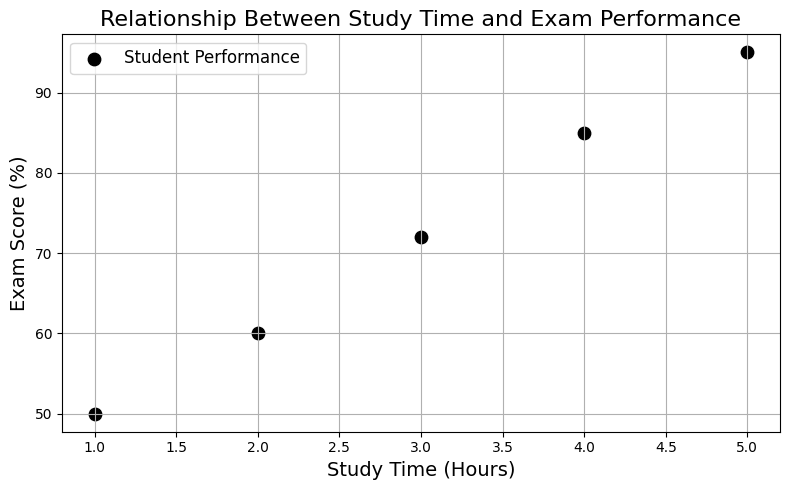

#### Level 2 description

A scatter plot titled 'relationship between study time and exam performance'. Study time (hours) is plotted on the x-axis from 0.5 to 5.5 and exam score (%) is plotted on the y-axis from 40 to 100, both using linear scales. Student performance is plotted in black. Student performance has 5 points, an average of x=3, an average of y=72.4, a linear fit of y=11.5x+37.9, and no outliers.
data table:

| study time (hours) | exam score (%) |
| ------------------ | -------------- |
| 1                  | 50             |
| 2                  | 60             |
| 3                  | 72             |
| 4                  | 85             |
| 5                  | 95             |


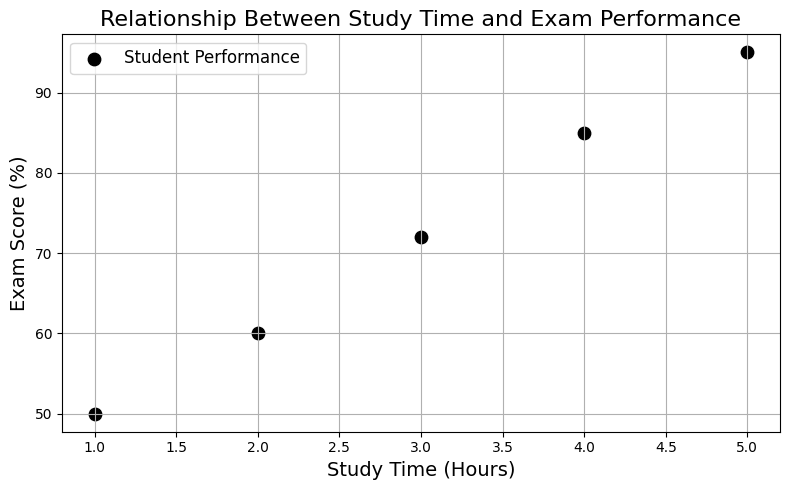

#### Level 3 description

A scatter plot titled 'relationship between study time and exam performance'. Study time (hours) is plotted on the x-axis from 0.5 to 5.5 and exam score (%) is plotted on the y-axis from 40 to 100, both using linear scales. Student performance is plotted in black. Student performance has 5 points, an average of x=3, an average of y=72.4, a linear fit of y=11.5x+37.9, and no outliers.
data table:

| study time (hours) | exam score (%) |
| ------------------ | -------------- |
| 1                  | 50             |
| 2                  | 60             |
| 3                  | 72             |
| 4                  | 85             |
| 5                  | 95             |


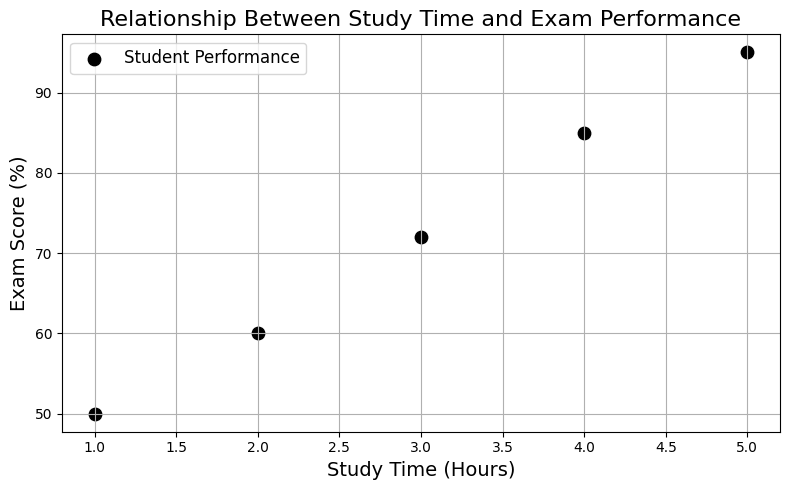

#### Level 4 description

**Level 4 was not generated because `OPENAI_API_KEY` is not set.** Set that environment variable and rerun this cell to generate the broader-context Level 4 description with MatplotAlt.

In [ ]:
def build_example_plot():
    study_hours = [1, 2, 3, 4, 5]
    exam_scores = [50, 60, 72, 85, 95]

    plt.figure(figsize=(8, 5))

    plt.scatter(
        study_hours,
        exam_scores,
        color="black",
        marker="o",
        s=80,
        label="Student Performance"
    )

    plt.xlabel("Study Time (Hours)", fontsize=14)
    plt.ylabel("Exam Score (%)", fontsize=14)
    plt.title("Relationship Between Study Time and Exam Performance", fontsize=16)

    plt.grid(True)
    plt.legend(fontsize=12)
    plt.tight_layout()


show_all_description_levels(
    build_example_plot,
    chart_type="scatter",
)

## Reusable accessible template

Replace the placeholder data and text with your own values. Keep the descriptive labels, meaningful title, readable text, high-contrast/redundant encodings where relevant, and the other accessibility features shown.

In [ ]:
# Replace the placeholder data and text below with your own values.
x_values = [1, 2, 3, 4, 5]
y_values = [12, 18, 21, 29, 34]

x_axis_label = "First variable (unit)"
y_axis_label = "Second variable (unit)"
graph_title = "Descriptive title explaining the relationship"
series_label = "Observed data"


def build_accessible_scatterplot():
    plt.figure(figsize=(8, 5))

    plt.scatter(
        x_values,
        y_values,
        color="black",
        marker="o",
        s=80,
        label=series_label
    )

    plt.xlabel(x_axis_label, fontsize=14)
    plt.ylabel(y_axis_label, fontsize=14)
    plt.title(graph_title, fontsize=16)

    plt.grid(True)
    plt.legend(fontsize=12)
    plt.tight_layout()


build_accessible_scatterplot()
plt.show()


### MatplotAlt descriptions for the template graph

Run the next cell after adapting the placeholders. It generates all four description levels in the same way as the shown example.

In [ ]:
show_all_description_levels(
    build_example_plot,
    chart_type="scatter",
)